# Fidélisation client dans le e-commerce: Analyse par modèle logit/probit

## Introduction

Ce projet examine les facteurs associés à la fidélisation des clients dans le secteur du e-commerce, à partir de données de transactions réelles issues d'un site de vente en ligne basé au Royaume-Uni (dataset Online Retail, période 2010-2011).

**Question de recherche** : quels facteurs liés au comportement d'achat (montant dépensé, quantité achetée, pays du client) sont associés à la probabilité qu'un client passe plusieurs commandes plutôt qu'une seule ?

**Démarche** : les données, initialement au niveau de la transaction, sont agrégées au niveau client afin de construire une variable binaire de fidélité (client ayant commandé plus d'une fois vs client ponctuel). Des modèles logit et probit sont ensuite estimés pour identifier les facteurs associés à cette fidélisation, avec une lecture des résultats à travers les effets marginaux.

In [62]:
# 1. IMPORT DES BIBLIOTHÈQUES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm 

## I-Import et préparation de la base de données

In [ ]:
df = pd.read_excel("C:\\Users\\SINED Shop\\Online Retail.xlsx")
df.head()

In [ ]:
df.info()

In [ ]:
df.shape

**Nettoyage des données**

In [ ]:
# Suppression des lignes sans CustomerID 
df = df.dropna(subset=["CustomerID"])

In [ ]:
#Suppression des commandes annulées 
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]


In [ ]:
#Suppression des quantités et prix négatifs ou nuls
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [ ]:
# Vérification des valeurs manquantes restantes
df.isna().sum()

In [ ]:
# Création d'une colonne montant total par ligne de commande
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

**Agrégation des données au niveau client**

In [ ]:
#regroupement par client
client_df = df.groupby("CustomerID").agg(
    nb_commandes=("InvoiceNo", "nunique"),       
    montant_total=("TotalPrice", "sum"),          
    quantite_totale=("Quantity", "sum"),          
    premiere_commande=("InvoiceDate", "min"),     
    derniere_commande=("InvoiceDate", "max"),     
    pays=("Country", "first")                     
).reset_index()

In [75]:
#Montant moyen par commande 
client_df["panier_moyen"] = client_df["montant_total"] / client_df["nb_commandes"]

client_df.head()
client_df.shape

(4338, 8)

**Construction de la variable cible (fidélité)**
**CONSTRUCTION DE LA VARIABLE BINAIRE (Y)**
**fidele = 1 si le client a commandé plus d'une fois, 0 sinon**

In [76]:
client_df["fidele"] = (client_df["nb_commandes"] > 1).astype(int)

In [77]:
# Répartition de la variable cible
client_df["fidele"].value_counts()
client_df["fidele"].value_counts(normalize=True)

fidele
1    0.655832
0    0.344168
Name: proportion, dtype: float64

## II-Statistiques descriptives

In [78]:
client_df.describe()

,CustomerID,nb_commandes,montant_total,quantite_totale,premiere_commande,derniere_commande,panier_moyen,fidele
count,4338.000000,4338.000000,4338.000000,4338.000000,4338,4338,4338.000000,4338.000000
mean,15300.408022,4.272015,2054.266460,1191.289073,2011-04-30 17:06:50.857538048,2011-09-08 11:38:59.045643008,419.166289,0.655832
min,12346.000000,1.000000,3.750000,1.000000,2010-12-01 08:26:00,2010-12-01 09:53:00,3.450000,0.000000
25%,13813.250000,1.000000,307.415000,160.000000,2011-01-17 11:13:15,2011-07-20 19:18:00,178.625000,0.000000
50%,15299.500000,2.000000,674.485000,379.000000,2011-04-05 09:52:30,2011-10-20 10:40:30,293.900000,1.000000
75%,16778.750000,5.000000,1661.740000,992.750000,2011-08-19 10:11:30,2011-11-22 11:05:45,430.113750,1.000000
max,18287.000000,209.000000,280206.020000,196915.000000,2011-12-09 12:16:00,2011-12-09 12:50:00,84236.250000,1.000000
std,1721.808492,7.697998,8989.230441,5046.081546,NaN,NaN,1796.537944,0.475151


La statistique descriptive révèle une forte asymétrie de quantite_totale et panier_moyen, avec des valeurs extrêmes très éloignées des médianes. Ces observations, probablement liées à des clients B2B ou grossistes peuvent entraîner des problèmes numériques lors de l’estimation des modèles logit et probit. Afin d’obtenir un échantillon plus homogène et de permettre l’estimation des modèles, les observations au-delà du 99e percentile de quantite_totale seront donc retirées.

In [79]:
##retirer les outliers
seuil_quantite = client_df["quantite_totale"].quantile(0.99)
seuil_panier = client_df["panier_moyen"].quantile(0.99)

client_df = client_df[
    (client_df["quantite_totale"] < seuil_quantite) &
    (client_df["panier_moyen"] < seuil_panier)
]

client_df[["panier_moyen", "quantite_totale"]].describe()

,panier_moyen,quantite_totale
count,4267.000000,4267.000000
mean,344.701199,809.801734
std,259.913489,1203.923820
min,3.450000,1.000000
25%,177.824286,158.000000
50%,288.770000,370.000000
75%,420.546667,942.000000
max,2027.860000,11005.000000


In [80]:
# Comparaison des moyennes entre fidèles et non-fidèles
client_df.groupby("fidele")[["montant_total", "panier_moyen", "quantite_totale"]].mean()

,montant_total,panier_moyen,quantite_totale
fidele,,,
0,331.039872,331.039872,202.151659
1,1948.019868,351.933379,1131.486022


## III-Analyse exploratoire

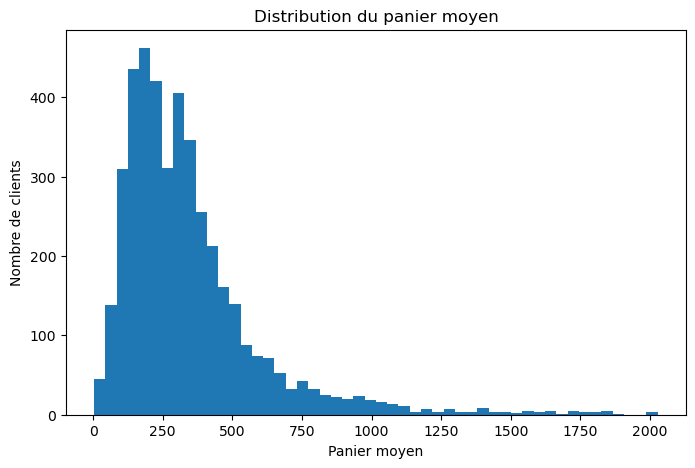

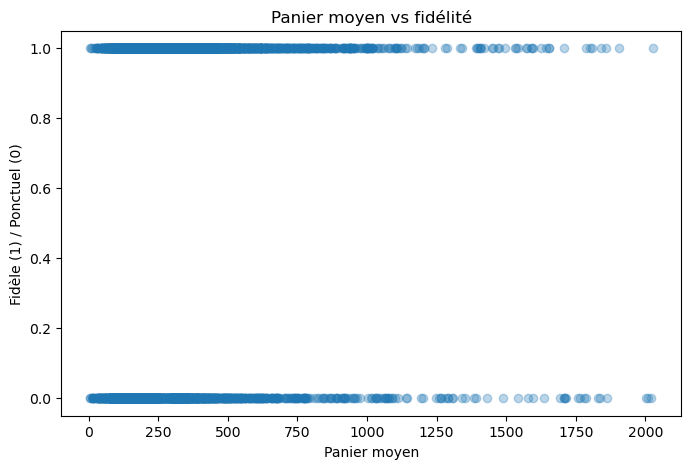

In [81]:
plt.figure(figsize=(8,5))
plt.hist(client_df["panier_moyen"], bins=50)
plt.xlabel("Panier moyen")
plt.ylabel("Nombre de clients")
plt.title("Distribution du panier moyen")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(client_df["panier_moyen"], client_df["fidele"], alpha=0.3)
plt.xlabel("Panier moyen")
plt.ylabel("Fidèle (1) / Ponctuel (0)")
plt.title("Panier moyen vs fidélité")
plt.show()

La distribution du panier moyen est fortement asymétrique à droite. La majorité des observations se concentre sur des niveaux de panier relativement faibles, tandis qu’un nombre limité de clients présentent des paniers exceptionnellement élevés. Ces valeurs extrêmes devront être prises en compte lors des analyses statistiques ultérieures.

**PRÉPARATION D'UNE VARIABLE PAYS SIMPLIFIÉE**

**Beaucoup de pays ont très peu de clients donc on garde les principaux, le reste en "Other"**

In [82]:
top_pays = client_df["pays"].value_counts().nlargest(5).index
client_df = client_df[
    (client_df["quantite_totale"] < seuil_quantite) &
    (client_df["panier_moyen"] < seuil_panier)
].copy()

**Corrélation entre les variables et fidele**

In [83]:
correlation_matrix = client_df[["fidele", "panier_moyen", "quantite_totale", "montant_total", "nb_commandes"]].corr()
print(correlation_matrix)

                   fidele  panier_moyen  quantite_totale  montant_total  \
fidele           1.000000      0.038248         0.367277       0.362288   
panier_moyen     0.038248      1.000000         0.406246       0.422490   
quantite_totale  0.367277      0.406246         1.000000       0.902738   
montant_total    0.362288      0.422490         0.902738       1.000000   
nb_commandes     0.423508      0.037384         0.726677       0.774277   

                 nb_commandes  
fidele               0.423508  
panier_moyen         0.037384  
quantite_totale      0.726677  
montant_total        0.774277  
nb_commandes         1.000000  


In [84]:
print(client_df.columns.tolist())

['CustomerID', 'nb_commandes', 'montant_total', 'quantite_totale', 'premiere_commande', 'derniere_commande', 'pays', 'panier_moyen', 'fidele']


## IV-Modélisation économétrique

**1-Modèle Logit**

In [56]:
logit_model = smf.logit(
    "fidele ~ panier_moyen + quantite_totale + C(pays_simplifie)",
    data=client_df
).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.322485
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                 fidele   No. Observations:                 4267
Model:                          Logit   Df Residuals:                     4259
Method:                           MLE   Df Model:                            7
Date:                Mon, 24 Aug 2026   Pseudo R-squ.:                  0.5000
Time:                        12:53:57   Log-Likelihood:                -1376.0
converged:                       True   LL-Null:                       -2752.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -0.0706      0.822

Le modèle logit affiche un pseudo R² de McFadden de 0,50, une valeur très élevée pour ce 
type de modèle (une valeur entre 0,2 et 0,4 est généralement considérée comme bonne), ce qui 
doit être interprété avec prudence compte tenu de l'avertissement de quasi-séparation signalé 
par le modèle (23% des observations parfaitement prédites). Les variables panier_moyen 
(coef = -0,0050) et quantite_totale (coef = 0,0056) sont toutes deux statistiquement 
significatives (p < 0,001), tandis qu'aucune des dummies de pays n'est significative, 
suggérant que le pays n'est pas associé à la fidélité une fois le comportement d'achat pris 
en compte. Les coefficients bruts n'étant pas directement interprétables en probabilité, 
l'analyse est complétée par les effets marginaux ci-dessous.

**2-Modèle Probit (comparaison)**

In [57]:
probit_model = smf.probit(
    "fidele ~ panier_moyen + quantite_totale + C(pays_simplifie)",
    data=client_df
).fit()

print(probit_model.summary())

Optimization terminated successfully.
         Current function value: 0.346386
         Iterations 17
                          Probit Regression Results                           
Dep. Variable:                 fidele   No. Observations:                 4267
Model:                         Probit   Df Residuals:                     4259
Method:                           MLE   Df Model:                            7
Date:                Mon, 24 Aug 2026   Pseudo R-squ.:                  0.4630
Time:                        12:54:03   Log-Likelihood:                -1478.0
converged:                       True   LL-Null:                       -2752.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               0.0099      0.462

Le modèle probit confirme les résultats du logit avec un pseudo R² proche (0,463) et le même 
signe pour les coefficients de panier_moyen (-0,0103) et quantite_totale (0,0123), tous deux 
significatifs à 1%. Comme pour le logit, aucune variable pays n'est significative. La 
convergence des deux modèles vers des conclusions similaires renforce la robustesse du 
résultat, malgré l'alerte de quasi-séparation qui appelle à une lecture prudente de la 
magnitude exacte des coefficients.

**3-Effets marginaux**

In [58]:
marginal_effects = logit_model.get_margeff()
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:                 fidele
Method:                          dydx
At:                           overall
                                         dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
C(pays_simplifie)[T.France]            -0.0316      0.094     -0.335      0.738      -0.217       0.153
C(pays_simplifie)[T.Germany]            0.0090      0.095      0.094      0.925      -0.178       0.196
C(pays_simplifie)[T.Other]              0.0371      0.091      0.409      0.682      -0.141       0.215
C(pays_simplifie)[T.Spain]              0.0159      0.107      0.149      0.881      -0.193       0.225
C(pays_simplifie)[T.United Kingdom]    -0.0268      0.087     -0.308      0.758      -0.197       0.144
panier_moyen                           -0.0011   3.17e-05    -34.436      0.000      -0.001      -0.001
quantite_totale 

Les effets marginaux du modèle logit permettent une lecture directe en probabilité : une 
augmentation d'une unité de quantite_totale augmente la probabilité d'être fidèle de 0,13 
point de pourcentage, ceteris paribus, tandis qu'une augmentation d'un euro du panier_moyen 
la diminue de 0,11 point. Ce dernier résultat peut sembler contre-intuitif au regard des 
statistiques descriptives, qui montraient un panier moyen plus élevé chez les clients 
fidèles. Cela s'explique probablement par une corrélation entre les deux variables 
explicatives : à quantité totale donnée, un panier moyen plus élevé reflète un prix unitaire 
plus élevé, ce qui pourrait être associé à des achats plus ponctuels plutôt qu'à un 
comportement d'achat récurrent.

# V-Discussion critique et limites

**1-Synthèse comparative des trois modèles**

Les trois analyses menées modèle logit, modèle probit et effets marginaux convergent vers des conclusions cohérentes. panier_moyen et quantite_totale sont systématiquement significatifs (p < 0,001) dans les deux spécifications (logit et probit), avec des signes identiques : un effet négatif du panier moyen et un effet positif de la quantité totale achetée sur la probabilité de fidélité. Les variables de pays, quant à elles, ne ressortent significatives dans aucun des deux modèles, suggérant que la localisation géographique du client n'explique pas la fidélité une fois le comportement d'achat pris en compte. Les effets marginaux permettent de traduire ces résultats en termes concrets : une hausse d'une unité de quantite_totale augmente la probabilité d'être fidèle de 0,13 point de pourcentage, contre une baisse de 0,11 point pour une hausse équivalente de panier_moyen. La stabilité des résultats entre logit et probit renforce la robustesse de ces conclusions, indépendamment du choix de la fonction de lien.

**2-Limites**

Plusieurs limites doivent être soulignées. Premièrement, les deux modèles ont signalé un risque de quasi-séparation complète (23% et 21% des observations parfaitement prédites), ce qui indique que certains clients sont classés avec une quasi-certitude par le modèle sur la seule base de leur comportement d'achat. Cette situation peut rendre l'estimation des coefficients instable et invite à interpréter leur magnitude exacte avec prudence, même si le sens des effets reste probablement fiable. Deuxièmement, la suppression des outliers (clients au-delà du 99e percentile de quantite_totale) était nécessaire pour permettre l'estimation numérique des modèles, mais elle exclut de fait les gros comptes (probablement B2B), ce qui limite la généralisation des résultats à l'ensemble de la clientèle. Troisièmement, la variable de fidélité utilisée ici est une mesure simple (plus d'une commande vs une seule), qui ne capture pas la temporalité ni l'intensité de la fidélité — un client ayant commandé deux fois à un mois d'intervalle est traité de la même façon qu'un client fidèle sur toute la période d'observation. Enfin, comme pour toute analyse de ce type, la relation mise en évidence reste associative et non causale : des facteurs non observés (type de produits achetés, canal d'acquisition du client, campagnes marketing ciblées) pourraient influencer à la fois le comportement d'achat initial et la probabilité de fidélisation.

# Conclusion

Cette analyse a permis d'identifier des facteurs de comportement d'achat associés à la fidélisation client dans un contexte e-commerce : un volume d'achat élevé est associé à une probabilité accrue de fidélité, tandis qu'un panier moyen élevé y est associé négativement, une fois le volume pris en compte. La cohérence des résultats entre les modèles logit et probit apporte une robustesse certaine à ces conclusions, malgré les limites méthodologiques identifiées, notamment le risque de quasi-séparation et les contraintes liées au traitement des valeurs extrêmes. D'un point de vue opérationnel, ces résultats suggèrent qu'une stratégie de fidélisation pourrait davantage cibler la fréquence et le volume d'achat plutôt que la valeur du panier, si l'objectif est de maximiser la rétention client.